# Cox Proportional Hazard Modeling 2: Gene Expression 
Now, we will do univariate testing of individual gene expression to see which effect survival the most

In [101]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
import pyhere as here
from collections import defaultdict

In [3]:
here.here()

PosixPath('/Users/jmakings/Documents/Projects/breast_cancer_survival_prediction')

### Preprocessing Functions

In [4]:
def preprocess_for_cox(df, duration_col, event_col):
    # Drop rows with missing values in duration or event columns
    df = df.dropna(subset=[duration_col, event_col])
    
    # Ensure duration column is numeric
    df[duration_col] = pd.to_numeric(df[duration_col], errors='coerce')
    
    # Drop rows with non-numeric duration values
    df = df.dropna(subset=[duration_col])
    
    return df

In [5]:
# converts float columns with whole numbers to integer type
def convert_whole_float_columns_to_int(df):
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            # Check if all non-null values are whole numbers
            if df[col].dropna().apply(float.is_integer).all():
                df[col] = df[col].astype("Int64")  # nullable integer type
    return df

In [6]:
def one_hot_encode(df, convert_whole_num_ints=True):
    # One hot encode categorical variables

    # Identify categorical columns automatically
    cat_cols = df.select_dtypes(include=["object", "category"]).columns

    # Apply one-hot encoding only to categorical columns
    df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    # Change boolean columns to integers
    bool_cols = df_encoded.select_dtypes(include=["bool"]).columns
    df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
    
    if convert_whole_num_ints:
        df_encoded = convert_whole_float_columns_to_int(df_encoded)
    return df_encoded

### Load data and Preprocess

In [7]:
# load clinical metadata with PCA + UMAP features
pca_clinical_df = pd.read_csv(here.here("data", "processed","clinical_dimred_features.csv"))

In [8]:
# load expression data
expression_data_df = pd.read_csv(here.here("data", "processed","expression_data.csv"))

In [9]:
# One hot encode categorical variables

df_encoded = one_hot_encode(pca_clinical_df)
df_encoded = convert_whole_float_columns_to_int(df_encoded)
# Rename for clarity
df_encoded = df_encoded.rename(columns={
    "overall_survival_months": "time",
    "death_from_cancer_Living": "event"
})

In [16]:
# gene expression data with time and cancer survival columns
survival_exp = pd.concat([df_encoded[["time","event"]], expression_data_df], axis=1)

# Ensure no time = 0 for proportional hazards testing
EPS = 1e-4  # or smaller if time is in months
survival_exp['time_adj'] = survival_exp['time'].clip(lower=EPS)

#### Time = 0 will cause runtime error when log-transforming, so we clip it to a very small number

In [18]:
(survival_exp['time']==0).sum()

1

In [17]:
(survival_exp['time_adj']==0).sum()

0

## Screen Genes Individually for Cox Modeling

We will look at each gene individually first, observing which genes violate our proportional hazard assumption

In [19]:
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

ph_results = []

for gene in expression_data_df.columns:
    print(f"Processing gene: {gene}")
    df_tmp = survival_exp[['time_adj', 'event', gene]].dropna()

    # Skip genes with near-zero variance
    if df_tmp[gene].std() < 1e-6:
        continue

    cph = CoxPHFitter()
    cph.fit(df_tmp, 'time_adj', 'event')

    # Perform proportional hazards test on log time to model early vs late effects better
    ph_test = proportional_hazard_test(cph, df_tmp, time_transform='log')

    ph_results.append({
        'gene': gene,
        'ph_p': ph_test.summary.loc[gene, 'p'],
        'coef': cph.params_[gene],
        'hr': cph.hazard_ratios_[gene],
    })

ph_df = pd.DataFrame(ph_results)
ph_df['ph_violation'] = ph_df['ph_p'] < 0.01



Processing gene: brca1
Processing gene: brca2
Processing gene: palb2
Processing gene: pten
Processing gene: tp53
Processing gene: atm
Processing gene: cdh1
Processing gene: chek2
Processing gene: nbn
Processing gene: nf1
Processing gene: stk11
Processing gene: bard1
Processing gene: mlh1
Processing gene: msh2
Processing gene: msh6
Processing gene: pms2
Processing gene: epcam
Processing gene: rad51c
Processing gene: rad51d
Processing gene: rad50
Processing gene: rb1
Processing gene: rbl1
Processing gene: rbl2
Processing gene: ccna1
Processing gene: ccnb1
Processing gene: cdk1
Processing gene: ccne1
Processing gene: cdk2
Processing gene: cdc25a
Processing gene: ccnd1
Processing gene: cdk4
Processing gene: cdk6
Processing gene: ccnd2
Processing gene: cdkn2a
Processing gene: cdkn2b
Processing gene: myc
Processing gene: cdkn1a
Processing gene: cdkn1b
Processing gene: e2f1
Processing gene: e2f2
Processing gene: e2f3
Processing gene: e2f4
Processing gene: e2f5
Processing gene: e2f6
Processing

### Create time interactions for genes violating porportional hazard

In [23]:
# create interaction terms for genes with proportional hazards violations
violating_genes = ph_df.loc[ph_df.ph_violation, 'gene'].tolist()

df_model = survival_exp.copy()

for gene in violating_genes:
    df_model[f'{gene}_logt'] = df_model[gene] * np.log(df_model['time_adj'])


In [ ]:
# 23 genes with proportional hazards violations
len(violating_genes)

23

In [24]:
df_model

,time,event,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,...,pdgfa_logt,ptk2_logt,asxl1_logt,asxl2_logt,fancd2_logt,sf3b1_logt,smarcc1_logt,tbl1xr1_logt,ubr5_logt,rdh5_logt
0,140.500000,1,-1.3990,-0.5738,-1.6217,1.4524,0.3504,1.1517,0.0348,0.1266,...,5.113345,-7.865847,3.155537,-7.026645,-10.373067,0.050936,-1.329272,-1.182894,-7.941509,24.779940
1,84.633333,1,-1.3800,0.2777,-1.2154,0.5296,-0.0136,-0.2659,1.3594,0.7961,...,-1.529448,-3.395765,-1.104256,3.436598,-3.155208,11.189025,-5.952242,-0.407439,2.267542,-2.812569
2,163.700000,0,0.0670,-0.8426,0.2114,-0.3326,0.5141,-0.0803,1.1398,0.4187,...,-7.105132,-5.400859,-9.624581,-11.698972,-3.140900,-3.358586,1.260234,-2.098861,2.514861,-3.851056
3,164.933333,1,0.6744,-0.5428,-1.6592,0.6369,1.6708,-0.8880,1.2491,-1.1889,...,-2.131564,13.421958,-8.654403,-9.022002,-1.472949,-3.163904,-3.526397,-2.263286,8.204094,-6.384479
4,41.366667,0,1.2932,-0.9039,-0.7219,0.2168,0.3484,0.3897,0.9131,0.9356,...,-4.481116,11.506916,-2.855883,-3.802136,-2.167970,3.872119,3.291041,-1.244796,11.544141,4.828423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,196.866667,1,0.1563,0.5543,-0.6149,0.4572,1.3822,-0.0537,-0.1323,0.2837,...,-0.983606,-6.882076,-4.802345,-4.372347,-1.297389,7.771653,0.864750,0.867391,-2.859960,-3.422021
1900,44.733333,0,0.1343,0.9128,1.3017,0.7383,0.1841,0.0028,0.1243,2.2040,...,-5.982712,-0.966903,-8.173066,0.521079,10.754514,-1.010611,-2.370128,-1.218510,1.063821,-2.386091
1901,175.966667,0,1.8107,-0.2608,0.4006,-0.2985,0.0356,-0.1620,1.5486,1.5309,...,-7.355778,-11.999220,-10.570667,-5.262326,0.414141,5.470689,3.881340,0.783817,4.545206,-8.460670
1902,86.233333,0,-1.2746,-1.7695,-0.3454,-0.3850,0.6689,1.4531,1.0956,-0.0948,...,-3.617347,-2.729502,-8.075296,-1.265804,-3.454219,7.010059,-1.525651,6.115528,-4.444131,-3.804544


### Create new model with all genes, including time covariates for genes violating PH

In [ ]:
# create interaction terms for genes with proportional hazards violations
violating_genes = ph_df.loc[ph_df.ph_violation, 'gene'].tolist()

df_model = survival_exp.copy()

for gene in violating_genes:
    df_model[f'{gene}_logt'] = df_model[gene] * np.log(df_model['time_adj'])

# Define model variables
base_genes = ph_df.loc[
    (ph_df.ph_violation == False) & (ph_df.ph_p > 0.05),
    'gene'
].tolist()

# genes without proportional hazards violations
len(base_genes)

435

In [ ]:
# create covariates list, combining base genes, violating genes, and their interaction terms
covariates = (
    base_genes +
    violating_genes +
    [f'{g}_logt' for g in violating_genes]
)

In [ ]:
# fit new model with interaction terms
# penalizer and l1_ratio are set to balance model complexity and avoid overfitting
cph = CoxPHFitter(penalizer=0.1, l1_ratio=0.5)
cph.fit(
    df_model[['time_adj', 'event'] + covariates],
    'time_adj',
    'event'
)

<lifelines.CoxPHFitter: fitted with 1904 total observations, 1103 right-censored observations>

In [31]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1904 total observations, 1103 right-censored observations>
             duration col = 'time_adj'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.5
      baseline estimation = breslow
   number of observations = 1904
number of events observed = 801
   partial log-likelihood = -4880.47
         time fit was run = 2025-12-23 23:11:14 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
brca1        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
brca2         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
pten         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
tp53          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cdh1         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
chek2         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
nbn           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
bard1        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
mlh1          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
msh2          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
msh6          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
pms2         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
epcam         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
rad51c        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
rad51d        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
rad50         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
rb1           0.03      1.03      0.04           -0.05            0.12                0.95                1.12
rbl1          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
ccna1         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
ccnb1        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cdk1         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
ccne1         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cdc25a        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
ccnd1        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cdk4          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cdk6          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
ccnd2         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cdkn2a        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cdkn2b        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
myc           0.05      1.05      0.04           -0.03            0.13                0.97                1.14
cdkn1b        0.00 

### Model Result
Many genes given coefficient of 0 due to L1 regularization.

### Next steps: 
1. Tune penalizer via k-fold cross validation with an array of penalizer values

In [32]:
from lifelines.utils import k_fold_cross_validation

for p in [0.001, 0.01, 0.05, 0.1]:
    cph = CoxPHFitter(penalizer=p, l1_ratio=0.5)
    scores = k_fold_cross_validation(
        cph,
        df_model[['time_adj', 'event'] + covariates],
        duration_col='time_adj',
        event_col='event',
        k=5,
        scoring_method="concordance_index"
    )
    print(p, np.mean(scores))


0.001 0.667591670559224
0.01 0.680085385054688


/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=1.04604e-16): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=7.99568e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=5.10617e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=3.92898e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/scipy/_lib/

0.05 0.7025629447900245
0.1 0.6856797684341873


#### *Looks like our best result is 0.05*
Lets run again to report variability between folds as well

In [34]:
for p in [.01, 0.05, 0.1]:
    cph = CoxPHFitter(penalizer=p, l1_ratio=0.5)
    scores = k_fold_cross_validation(
        cph,
        df_model[['time_adj', 'event'] + covariates],
        duration_col='time_adj',
        event_col='event',
        k=5,
        scoring_method="concordance_index"
    )
    print(p, np.mean(scores), np.std(scores))


0.01 0.68896876946122 0.013552222281408592
0.05 0.6958899636476539 0.022983090331030468
0.1 0.6831134291436666 0.01390431116268099


In [ ]:
# now, we refit the model with genes only with the best penalizer
cph_final = CoxPHFitter(penalizer=0.05, l1_ratio=0.5)
cph_final.fit(
    df_model[['time_adj', 'event'] + covariates],
    'time_adj',
    'event'
)

<lifelines.CoxPHFitter: fitted with 1904 total observations, 1103 right-censored observations>

In [65]:
pd.set_option('display.max_rows', 100) # Show all rows

cph_final.summary.sort_values("coef", key=abs, ascending=False)[:15]

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
hsd17b11,0.118058,1.125310,0.062691,-0.004814,0.240930,0.995198,1.272432,0.0,1.883182,0.059676,4.066714
sf3b1,0.107958,1.114001,0.056885,-0.003536,0.219451,0.996471,1.245393,0.0,1.897811,0.057721,4.114762
cxcr1,0.101866,1.107235,0.041919,0.019706,0.184025,1.019901,1.202046,0.0,2.430059,0.015096,6.049654
arid1a,0.092153,1.096532,0.048934,-0.003757,0.188063,0.996250,1.206909,0.0,1.883194,0.059674,4.066752
pdpk1,0.091177,1.095463,0.052207,-0.011146,0.193500,0.988916,1.213490,0.0,1.746471,0.080729,3.630767
tsc1,-0.075097,0.927654,0.047669,-0.168526,0.018333,0.844909,1.018502,0.0,-1.575375,0.115170,3.118163
tnk2,-0.074817,0.927913,0.049959,-0.172736,0.023101,0.841360,1.023370,0.0,-1.497563,0.134247,2.897041
rb1,0.074763,1.077629,0.048768,-0.020820,0.170347,0.979395,1.185716,0.0,1.533038,0.125267,2.996927
star,0.066247,1.068491,0.037714,-0.007670,0.140165,0.992359,1.150464,0.0,1.756579,0.078990,3.662193


### Here, by sorting for coefficient absolute value, we can determine which genes are actually predictive of survival and which are "zeroed out" due to regularization. For the final model, we will pick clinical variables with coef > abs(0.05)

# Clinical + Gene Expression Model
## Next, we will combine all of our covariates (both clinical and gene expression) into a single model, and determine which features are most predictive

In [56]:
# add clinical features from clinical modeling notebook
clinical_cols = [
    # "overall_survival_months",   # time (already included as time_adj )
    # "death_from_cancer",         # event (already included in df_model)
    "age_at_diagnosis",          
    "tumor_size",
    "lymph_nodes_examined_positive",
    "neoplasm_histologic_grade",
    "er_status",
    "pr_status",
    "her2_status", 
    # additional features to test
    "chemotherapy", 
    "radio_therapy",
    "inferred_menopausal_state", 
    "pam50_+_claudin-low_subtype",
    #"primary_tumor_laterality"
]

In [ ]:
# To do: preprocess clinical data, add this to model with gene expression, refit model, and bootstrap 

# clinical data for modeling
clinical_selected = pca_clinical_df[clinical_cols]

df_encoded = one_hot_encode(clinical_selected)
df_encoded = convert_whole_float_columns_to_int(df_encoded)
# Rename for clarity
df_encoded = df_encoded.rename(columns={
    "overall_survival_months": "time",
    "death_from_cancer_Living": "event"
})

In [85]:
# reduce gene expression data to only include abs(coef) > 0.05 from final model
# active_set = cph_final.summary.sort_values("coef", key=abs, ascending=False)[:13].index.tolist()
# active_set

In [74]:
# combine clinical and gene expression data. First, we will try it with all gene expression features
df_combined = pd.concat([df_encoded, df_model[['time_adj', 'event'] +  covariates]],axis=1)

In [93]:
# remove rows with missing data
df_combined.dropna(inplace=True)

In [96]:
# dataset with clinical and expression data
df_combined

,age_at_diagnosis,tumor_size,lymph_nodes_examined_positive,neoplasm_histologic_grade,chemotherapy,radio_therapy,er_status_Positive,pr_status_Positive,her2_status_Positive,inferred_menopausal_state_Pre,...,pdgfa_logt,ptk2_logt,asxl1_logt,asxl2_logt,fancd2_logt,sf3b1_logt,smarcc1_logt,tbl1xr1_logt,ubr5_logt,rdh5_logt
0,75.65,22.0,10,3,0,1,1,0,0,0,...,5.113345,-7.865847,3.155537,-7.026645,-10.373067,0.050936,-1.329272,-1.182894,-7.941509,24.779940
1,43.19,10.0,0,3,0,1,1,1,0,1,...,-1.529448,-3.395765,-1.104256,3.436598,-3.155208,11.189025,-5.952242,-0.407439,2.267542,-2.812569
2,48.87,15.0,1,2,1,0,1,1,0,1,...,-7.105132,-5.400859,-9.624581,-11.698972,-3.140900,-3.358586,1.260234,-2.098861,2.514861,-3.851056
3,47.68,25.0,3,2,1,1,1,1,0,1,...,-2.131564,13.421958,-8.654403,-9.022002,-1.472949,-3.163904,-3.526397,-2.263286,8.204094,-6.384479
4,76.97,40.0,8,3,1,1,1,1,0,0,...,-4.481116,11.506916,-2.855883,-3.802136,-2.167970,3.872119,3.291041,-1.244796,11.544141,4.828423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,43.10,25.0,1,3,0,1,1,1,0,1,...,-0.983606,-6.882076,-4.802345,-4.372347,-1.297389,7.771653,0.864750,0.867391,-2.859960,-3.422021
1900,42.88,20.0,1,3,0,1,1,0,1,1,...,-5.982712,-0.966903,-8.173066,0.521079,10.754514,-1.010611,-2.370128,-1.218510,1.063821,-2.386091
1901,62.90,25.0,45,3,0,1,1,1,0,0,...,-7.355778,-11.999220,-10.570667,-5.262326,0.414141,5.470689,3.881340,0.783817,4.545206,-8.460670
1902,61.16,25.0,12,2,0,0,1,1,0,0,...,-3.617347,-2.729502,-8.075296,-1.265804,-3.454219,7.010059,-1.525651,6.115528,-4.444131,-3.804544


## Fit model with all gene expression + clinical features

In [97]:
# Fit model
cph = CoxPHFitter(penalizer=0.05, l1_ratio=0.5)
cph.fit(
    df_combined,
    duration_col='time_adj',
    event_col='event', 
    strata=["chemotherapy", "radio_therapy"] # stratify by treatment variables to account for their effects on baseline hazard
)

<lifelines.CoxPHFitter: fitted with 1815 total observations, 1041 right-censored observations>

In [99]:
cph.print_summary()

model,lifelines.CoxPHFitter
duration col,'time_adj'
event col,'event'
penalizer,0.05
l1 ratio,0.5
strata,"[chemotherapy, radio_therapy]"
baseline estimation,breslow
number of observations,1815
number of events observed,774
partial log-likelihood,-3743.34
time fit was run,2026-01-11 23:46:11 UTC


## Bootstrap 
We will now bootstrap the data to test the stability of the model. 
To do this, we will keep all clinical covariates in the data, and bootstrap gene expression data to see which genes are most stable and predictive

In [104]:
# define values in dataframe
SURVIVAL_COLS = ["time_adj", "event"]
STRATA_COLS = ["chemotherapy", "radio_therapy"]

clinical_cols = [
    # "overall_survival_months",   # time (already included as time_adj )
    # "death_from_cancer",         # event (already included in df_model)
    "age_at_diagnosis",          
    "tumor_size",
    "lymph_nodes_examined_positive",
    "neoplasm_histologic_grade",
    "er_status",
    "pr_status",
    "her2_status", 
    # additional features to test
    "chemotherapy", 
    "radio_therapy",
    "inferred_menopausal_state", 
    "pam50_+_claudin-low_subtype",
    #"primary_tumor_laterality"
]

gene_cols = [
    c for c in df_combined.columns
    if c not in SURVIVAL_COLS + STRATA_COLS + clinical_cols
]


In [116]:
len(gene_cols), len(clinical_cols)

(491, 11)

In [122]:
cph = CoxPHFitter(penalizer=0.05, l1_ratio=0.5)

cph.fit(
    df_combined,
    duration_col="time_adj",
    event_col="event",
    strata=STRATA_COLS
)

final_coefs = cph.params_


## Setup bootstrap
We will start with 200 bootstraps (random sampling with replacement) to determine the most stable and predictive genes

In [ ]:
n_bootstraps = 200
ACTIVE_PERCENTILE = 95   # top 5% strongest genes per bootstrap

selection_counts = defaultdict(int)
signs = defaultdict(list)

np.random.seed(42)

In [ ]:
for b in range(n_bootstraps):

    # Resample patients with replacement
    boot_idx = np.random.choice(
        df_combined.index,
        size=len(df_combined),
        replace=True
    )
    df_boot = df_combined.loc[boot_idx]

    # penalizer incrased to improve convergence in bootstrapping
    cph_boot = CoxPHFitter(penalizer=0.05, l1_ratio=0.5)

    try:
        cph_boot.fit(
            df_boot,
            duration_col="time_adj",
            event_col="event",
            strata=STRATA_COLS
        )
    except Exception:
        continue  # convergence failures are OK in bootstrapping

    boot_coefs = cph_boot.params_

    # ---- IMPORTANT PART ----
    # Only genes participate in active-set definition
    gene_coefs = boot_coefs.loc[gene_cols].dropna()
    abs_gene_coefs = gene_coefs.abs()

    if len(abs_gene_coefs) == 0:
        continue

    threshold = np.percentile(abs_gene_coefs, ACTIVE_PERCENTILE)
    active_genes = abs_gene_coefs[abs_gene_coefs >= threshold]

    for gene in active_genes.index:
        selection_counts[gene] += 1
        signs[gene].append(np.sign(gene_coefs[gene]))

    if (b+1) % 10 == 0:
        print(f"Completed bootstrap {b+1}/{n_bootstraps}")


/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=7.47209e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=5.64393e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=4.35853e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=3.37496e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/scipy/_lib/

KeyboardInterrupt: 

In [ ]:
stability_df = pd.DataFrame({
    "selection_freq": {
        g: selection_counts[g] / n_bootstraps
        for g in gene_cols
    },
    "sign_consistency": {
        g: (
            np.mean(np.sign(final_coefs[g]) == np.array(signs[g]))
            if len(signs[g]) > 0 else np.nan
        )
        for g in gene_cols
    },
    "final_coef": final_coefs.loc[gene_cols]
})


In [ ]:
stable_genes = stability_df[
    (stability_df["selection_freq"] >= 0.6) &
    (stability_df["sign_consistency"] >= 0.9)
].sort_values("selection_freq", ascending=False)


In [ ]:
stable_genes

### Results: 200 bootstraps took too long to converge, so we will try a new method

In [130]:
# define values in dataframe
SURVIVAL_COLS = ["time_adj", "event"]
STRATA_COLS = ["chemotherapy", "radio_therapy"]

# Required columns
TIME_COL = "time_adj"
EVENT_COL = "event"

clinical_cols = [
    # "overall_survival_months",   # time (already included as time_adj )
    # "death_from_cancer",         # event (already included in df_model)
    "age_at_diagnosis",          
    "tumor_size",
    "lymph_nodes_examined_positive",
    "neoplasm_histologic_grade",
    "er_status",
    "pr_status",
    "her2_status", 
    # additional features to test
    "chemotherapy", 
    "radio_therapy",
    "inferred_menopausal_state", 
    "pam50_+_claudin-low_subtype",
    #"primary_tumor_laterality"
]

gene_cols = [
    c for c in df_combined.columns
    if c not in SURVIVAL_COLS + STRATA_COLS + clinical_cols
]

In [131]:
# global parameters for bootstrapping

N_BOOTSTRAPS = 100
PENALIZER = 0.2
L1_RATIO = 0.5
ACTIVE_SET_PERCENTILE = 95
GENE_VAR_THRESHOLD = 0.3


In [135]:
# filter genes by variance threshold
gene_vars = df_combined[gene_cols].var()
gene_cols = gene_vars[gene_vars > GENE_VAR_THRESHOLD].index.tolist()

print(f"Genes retained after filtering: {len(gene_cols)} out of {len(gene_cols)}")


Genes retained after filtering: 481 out of 481


In [137]:
# define modeling dataframe
# model_cols = (
#     [TIME_COL, EVENT_COL]
#     + clinical_cols
#     + gene_cols
# )

# we retain the complete dataset
df_model = df_combined

In [138]:
# create function for single bootstrap run
import numpy as np
from lifelines import CoxPHFitter

def run_single_bootstrap(seed):
    np.random.seed(seed)

    # Resample patients
    boot_idx = np.random.randint(0, len(df_model), len(df_model))
    df_boot = df_model.iloc[boot_idx]

    cph = CoxPHFitter(
        penalizer=PENALIZER,
        l1_ratio=L1_RATIO, 
        strata=STRATA_COLS
    )

    try:
        cph.fit(
            df_boot,
            duration_col=TIME_COL,
            event_col=EVENT_COL
        )
    except Exception:
        return None

    # Extract gene coefficients only
    coefs = cph.params_.loc[gene_cols].dropna()

    if coefs.empty:
        return None

    abs_coefs = coefs.abs()
    threshold = np.percentile(abs_coefs, ACTIVE_SET_PERCENTILE)

    active_genes = abs_coefs[abs_coefs >= threshold].index.tolist()

    return {
        "genes": active_genes,
        "signs": np.sign(coefs.loc[active_genes]).to_dict()
    }

In [139]:
# paralelize bootstrapping

from joblib import Parallel, delayed

results = Parallel(
    n_jobs=-1,
    backend="loky",
    verbose=10
)(
    delayed(run_single_bootstrap)(i)
    for i in range(N_BOOTSTRAPS)
)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  3.2min
/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['pam50_+_claudin-low_subtype_NC'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/lifelines/utils/__init__.py:797: RuntimeWarning: invalid value encountered in divide
  return (X - mean) / std
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  6.4min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed: 10.8min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed: 15.9min
[Paralle

In [140]:
# aggregate results

from collections import defaultdict

selection_counts = defaultdict(int)
signs = defaultdict(list)

for res in results:
    if res is None:
        continue
    for g in res["genes"]:
        selection_counts[g] += 1
        signs[g].append(res["signs"][g])

# Convert to dataframe
import pandas as pd

stability_df = pd.DataFrame({
    "gene": list(selection_counts.keys()),
    "selection_frequency": [
        selection_counts[g] / N_BOOTSTRAPS
        for g in selection_counts
    ],
    "sign_consistency": [
        abs(np.mean(signs[g]))
        for g in selection_counts
    ]
}).sort_values("selection_frequency", ascending=False)


In [181]:
# final stable gene set
stable_genes = stability_df[
    (stability_df["selection_frequency"] >= 0.25) &
    (stability_df["sign_consistency"] >= 0.8)
]

print(f"Stable genes selected: {len(stable_genes)}")


Stable genes selected: 29


In [182]:
stable_genes

,gene,selection_frequency,sign_consistency
2,jak1,0.98,1.0
24,sf3b1_logt,0.98,1.0
23,sf3b1,0.98,1.0
1,rb1,0.98,1.0
11,pdpk1,0.98,1.0
18,hsd17b11,0.98,1.0
16,kmt2c,0.97,1.0
22,casp8,0.96,1.0
15,arid1a,0.93,1.0
21,ran,0.89,1.0


In [183]:
stable_genes_list = stable_genes["gene"].tolist()
stable_genes_list.remove('sf3b1')

In [184]:
stable_genes_list

['jak1',
 'sf3b1_logt',
 'rb1',
 'pdpk1',
 'hsd17b11',
 'kmt2c',
 'casp8',
 'arid1a',
 'ran',
 'myc',
 'hsd3b7',
 'tgfbr2',
 'mlh1',
 'tnk2',
 'smad7',
 'ep300',
 'akt1s1',
 'casp6',
 'stat3',
 'folr2',
 'stat2',
 'adam17',
 'tsc1',
 'maml3',
 'cxcr1',
 'casp10',
 'ubr5',
 'smad2']

In [185]:
df_combined.iloc[:,:18]

,age_at_diagnosis,tumor_size,lymph_nodes_examined_positive,neoplasm_histologic_grade,chemotherapy,radio_therapy,er_status_Positive,pr_status_Positive,her2_status_Positive,inferred_menopausal_state_Pre,pam50_+_claudin-low_subtype_Her2,pam50_+_claudin-low_subtype_LumA,pam50_+_claudin-low_subtype_LumB,pam50_+_claudin-low_subtype_NC,pam50_+_claudin-low_subtype_Normal,pam50_+_claudin-low_subtype_claudin-low,time_adj,event
0,75.65,22.0,10,3,0,1,1,0,0,0,0,0,0,0,0,1,140.500000,1
1,43.19,10.0,0,3,0,1,1,1,0,1,0,1,0,0,0,0,84.633333,1
2,48.87,15.0,1,2,1,0,1,1,0,1,0,0,1,0,0,0,163.700000,0
3,47.68,25.0,3,2,1,1,1,1,0,1,0,0,1,0,0,0,164.933333,1
4,76.97,40.0,8,3,1,1,1,1,0,0,0,0,1,0,0,0,41.366667,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,43.10,25.0,1,3,0,1,1,1,0,1,0,1,0,0,0,0,196.866667,1
1900,42.88,20.0,1,3,0,1,1,0,1,1,0,0,1,0,0,0,44.733333,0
1901,62.90,25.0,45,3,0,1,1,1,0,0,0,0,1,0,0,0,175.966667,0
1902,61.16,25.0,12,2,0,0,1,1,0,0,0,0,1,0,0,0,86.233333,0


In [186]:
df_combined.loc[:,stable_genes_list]

,jak1,sf3b1_logt,rb1,pdpk1,hsd17b11,kmt2c,casp8,arid1a,ran,myc,...,stat3,folr2,stat2,adam17,tsc1,maml3,cxcr1,casp10,ubr5,smad2
0,1.1097,0.050936,-0.2770,-0.2005,1.6822,-0.9045,0.1816,-1.2999,0.6630,2.5602,...,0.9765,1.0893,-0.7556,0.8721,0.0623,-1.5365,0.9278,0.3033,-1.6059,0.7905
1,0.9804,11.189025,-1.7488,0.2841,-0.7837,-0.0208,1.8819,1.9157,-0.2505,0.7248,...,-0.8428,-0.9169,-0.7991,-0.2006,0.8054,-0.1651,-1.2491,0.1039,0.5109,1.1109
2,1.5835,-3.358586,1.4142,-0.4960,1.6822,-0.5063,0.6432,-0.9847,0.2707,-0.7207,...,-0.2243,0.5313,-1.3487,-1.1229,-0.9652,-0.6574,0.0089,-0.8205,0.4933,-1.0038
3,0.6194,-3.163904,1.5345,-0.7175,1.4099,-1.2840,-1.1012,-1.5992,1.7962,-0.5237,...,-1.2401,1.3413,-0.5512,-1.0490,-0.6103,-0.8255,-0.0706,1.2658,1.6069,0.4072
4,0.0461,3.872119,1.0158,1.4198,0.0493,-1.1026,1.8931,0.5634,1.2930,0.5223,...,-0.5049,0.6556,0.3308,-0.2383,-0.7420,-2.1710,-0.9502,0.1754,3.1012,-0.7546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,1.3329,7.771653,1.1341,-0.0361,1.5955,-0.7792,1.7063,-0.7148,1.4046,0.4000,...,1.0668,1.0170,-0.9786,-0.3600,-0.2158,-0.4006,-0.6513,-0.0163,-0.5414,-0.0048
1900,-0.1851,-1.010611,0.4500,1.7397,0.2741,-0.9098,-0.2765,-0.9123,0.8469,-0.0430,...,-0.8253,-0.1741,-1.4386,0.3862,0.1450,-1.3119,0.4195,-1.6358,0.2799,0.2265
1901,0.5161,5.470689,0.9070,0.7885,0.3877,-0.3638,2.3513,-0.8813,2.1818,2.0526,...,0.3966,-0.0257,-1.6392,0.1968,-1.6078,-1.6289,-0.1224,1.9447,0.8791,0.5264
1902,1.2830,7.010059,0.0080,1.6513,0.6109,-0.4029,2.9647,0.5087,1.3851,0.0151,...,-1.1179,0.5692,-0.9625,0.2951,0.2223,-0.3767,-0.4862,1.4720,-0.9971,-0.6755


In [187]:
# final model with clinical covariates + stable genes

final_covariates = (
    list(df_combined.iloc[:,:16].columns) +
    stable_genes_list
)

final_df = df_combined[
    [TIME_COL, EVENT_COL] + final_covariates
].dropna()

final_cph = CoxPHFitter(penalizer=0.01)
final_cph.fit(
    final_df,
    duration_col=TIME_COL,
    event_col=EVENT_COL, 
    strata=STRATA_COLS
)

final_cph.print_summary()


model,lifelines.CoxPHFitter
duration col,'time_adj'
event col,'event'
penalizer,0.01
l1 ratio,0.0
strata,"[chemotherapy, radio_therapy]"
baseline estimation,breslow
number of observations,1815
number of events observed,774
partial log-likelihood,-3682.52
time fit was run,2026-01-13 04:45:07 UTC


# Plots showcasing model findings

## Forest Plot of Top Coefficients
#### Most predictive coefficients in final cox model

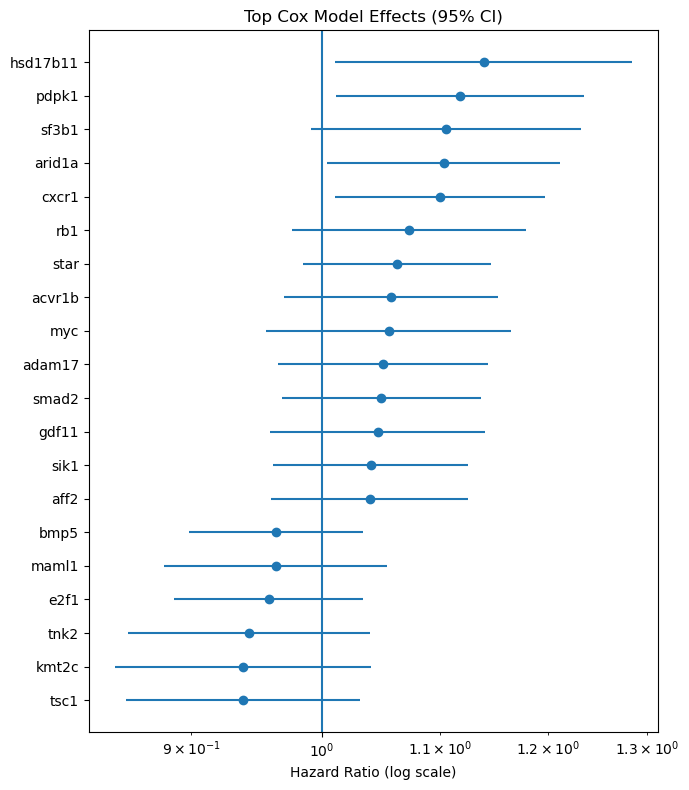

In [188]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract summary table
summary = cph.summary.copy()

# Select strongest effects (by absolute z-score)
top = (
    summary
    .assign(abs_z=summary["z"].abs())
    .sort_values("abs_z", ascending=False)
    .head(20)
    .sort_values("coef")
)

plt.figure(figsize=(7, 8))
plt.errorbar(
    top["exp(coef)"],
    top.index,
    xerr=[
        top["exp(coef)"] - top["exp(coef) lower 95%"],
        top["exp(coef) upper 95%"] - top["exp(coef)"],
    ],
    fmt="o"
)

plt.axvline(1.0)
plt.xlabel("Hazard Ratio (log scale)")
plt.xscale("log")
plt.title("Top Cox Model Effects (95% CI)")
plt.tight_layout()
plt.show()


### Kaplan-Meier Curves by Risk Group

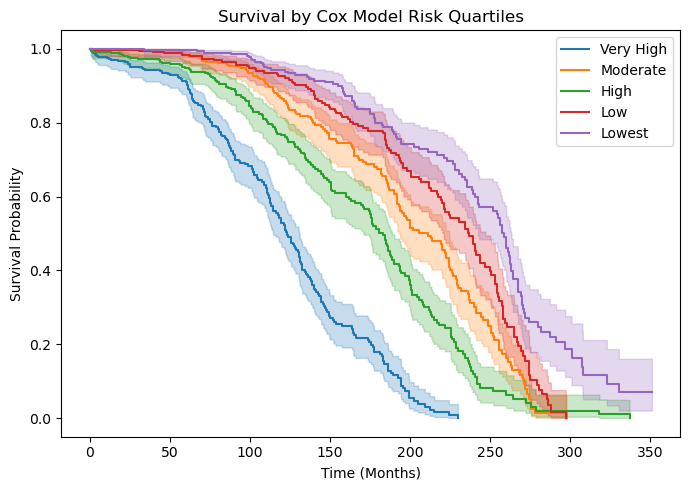

In [196]:
from lifelines import KaplanMeierFitter

# Compute risk scores
df_combined["risk_score"] = cph.predict_partial_hazard(df_combined)

# Define risk groups
df_combined["risk_group"] = pd.qcut(
    df_combined["risk_score"],
    #q=4, labels=["Low", "Mid-Low", "Mid-High", "High"],
    q=5, labels=["Lowest", "Low", "Moderate", "High", "Very High"]
)

kmf = KaplanMeierFitter()

plt.figure(figsize=(7, 5))

for group in df_combined["risk_group"].unique():
    ix = df_combined["risk_group"] == group
    kmf.fit(
        df_combined.loc[ix, "time_adj"],
        event_observed=df_combined.loc[ix, "event"],
        label=group
    )
    kmf.plot_survival_function()

plt.title("Survival by Cox Model Risk Quartiles")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.tight_layout()
plt.show()


#### From this Kaplan-Meier Plot, we can see that the model clearly predicts Highest-Risk indviduals compared to others, and maintains separation between groups until ~day 275

## Distribution of Predicted Risk Scores

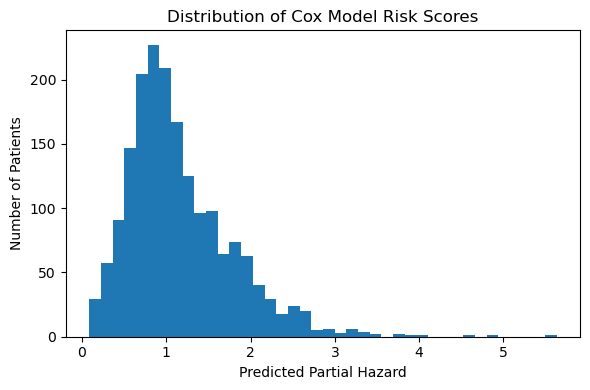

In [193]:
plt.figure(figsize=(6, 4))
plt.hist(df_combined["risk_score"], bins=40)
plt.xlabel("Predicted Partial Hazard")
plt.ylabel("Number of Patients")
plt.title("Distribution of Cox Model Risk Scores")
plt.tight_layout()
plt.show()


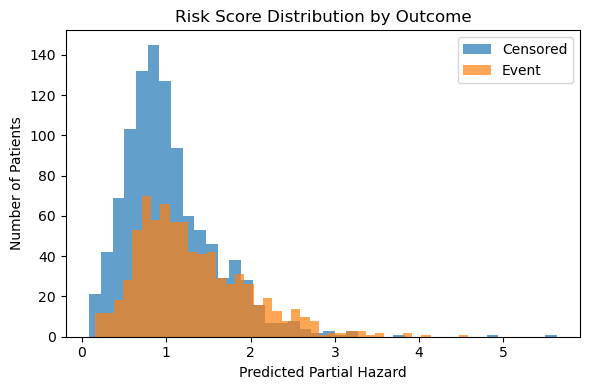

In [194]:
plt.figure(figsize=(6, 4))
plt.hist(df_combined.loc[df_combined["event"] == 0, "risk_score"], bins=40, alpha=0.7, label="Censored")
plt.hist(df_combined.loc[df_combined["event"] == 1, "risk_score"], bins=40, alpha=0.7, label="Event")
plt.xlabel("Predicted Partial Hazard")
plt.ylabel("Number of Patients")
plt.legend()
plt.title("Risk Score Distribution by Outcome")
plt.tight_layout()
plt.show()


## Time-dependent survival curves for representative patients

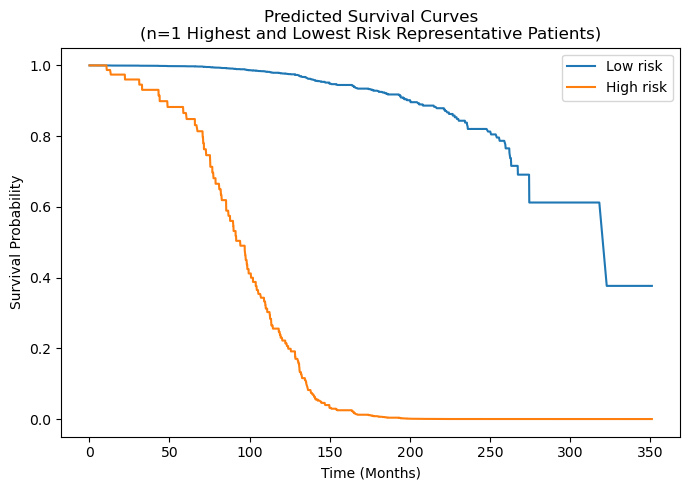

In [199]:
# Choose representative patients
low_risk = df_combined.nsmallest(1, "risk_score")
high_risk = df_combined.nlargest(1, "risk_score")

plt.figure(figsize=(7, 5))

for label, row in [("Low risk", low_risk), ("High risk", high_risk)]:
    surv = cph.predict_survival_function(row)
    plt.plot(surv.index, surv.values.flatten(), label=label)

plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.title("Predicted Survival Curves\n(n=1 Highest and Lowest Risk Representative Patients)")
plt.legend()
plt.tight_layout()
plt.show()


## Schoenfeld Residual Check for key variables

In [ ]:
# Columns used in the fitted Cox model
covariates = cph.params_.index.tolist()

# Strata columns (can be string or list)
strata_cols = (
    [cph.strata] if isinstance(cph.strata, str) else list(cph.strata)
)

# Build the exact dataframe needed for PH checks
df_ph = df_combined[
    [cph.duration_col, cph.event_col] + strata_cols + covariates
].copy()

# Ensure unique index (lifelines requirement)
df_ph = df_ph.reset_index(drop=True)

cph.check_assumptions(
    df_ph,
    p_value_threshold=0.05,
    show_plots=True
)



   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lin

/Users/jmakings/miniconda3/envs/bc_survival/lib/python3.11/site-packages/lifelines/fitters/mixins.py:123: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()



   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lin